In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree
import matplotlib.pyplot as plt

# =========================
# 1. 데이터 로드
# =========================
df = pd.read_csv("../DATA/PROCESS/save_dataset3.csv")

hidden = pd.read_csv("../RESULT/final_selected_j_analysis_dataset.csv")
excl = pd.read_csv("../DATA/LOCAL/excl.csv")

# =========================
# 2. 혼잡 지역(target=1)
# =========================
H = df[df["target"] == 1].copy()

# 중복 좌표 제거
H = H.drop_duplicates(
    subset=["위도", "경도"]
)

# =========================
# 3. 좌표 정리
# =========================
H = H.dropna(subset=["위도", "경도"])
hidden = hidden.dropna(subset=["위도", "경도"])
excl = excl.dropna(subset=["위도", "경도"])

# =========================
# 4. 소외상권 BallTree
# =========================
EARTH_RADIUS_M = 6371000

excl_rad = np.radians(
    excl[["위도", "경도"]].values
)

tree = BallTree(
    excl_rad,
    metric="haversine"
)

# =========================
# 5. 기존 핫플 거리 계산
# =========================
H_rad = np.radians(
    H[["위도", "경도"]].values
)

dist_H, _ = tree.query(H_rad, k=1)

H["nearest_excl_dist_m"] = (
    dist_H[:, 0] * EARTH_RADIUS_M
)

# =========================
# 6. Hidden Spot 거리 계산
# =========================
hidden_rad = np.radians(
    hidden[["위도", "경도"]].values
)

dist_hidden, _ = tree.query(hidden_rad, k=1)

hidden["nearest_excl_dist_m"] = (
    dist_hidden[:, 0] * EARTH_RADIUS_M
)

# =========================
# 7. 거리 통계 출력
# =========================
print("=== Existing Hotspots (target=1) ===")
print(
    H["nearest_excl_dist_m"].describe()
)

print("\n=== Hidden Spots ===")
print(
    hidden["nearest_excl_dist_m"].describe()
)

=== Existing Hotspots (target=1) ===
count      97.000000
mean     1915.442506
std      1037.726824
min        96.259595
25%      1125.383550
50%      1844.350279
75%      2703.326002
max      5321.852621
Name: nearest_excl_dist_m, dtype: float64

=== Hidden Spots ===
count      21.000000
mean     1887.479631
std      1038.546661
min       138.036126
25%       934.515599
50%      1971.803602
75%      2822.412956
max      3751.712167
Name: nearest_excl_dist_m, dtype: float64


/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_46300/2609167783.py:67: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hidden["nearest_excl_dist_m"] = (


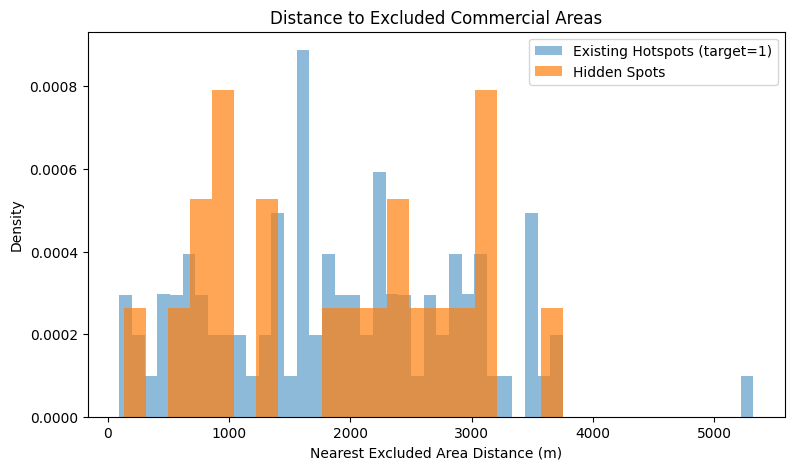

In [2]:
# =========================
# 8. 거리 분포 비교
# =========================
plt.figure(figsize=(9,5))

plt.hist(
    H["nearest_excl_dist_m"],
    bins=50,
    alpha=0.5,
    label="Existing Hotspots (target=1)",
    density=True
)

plt.hist(
    hidden["nearest_excl_dist_m"],
    bins=20,
    alpha=0.7,
    label="Hidden Spots",
    density=True
)

plt.xlabel(
    "Nearest Excluded Area Distance (m)"
)

plt.ylabel("Density")

plt.title(
    "Distance to Excluded Commercial Areas"
)

plt.legend()

plt.show()

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_46300/1670527689.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


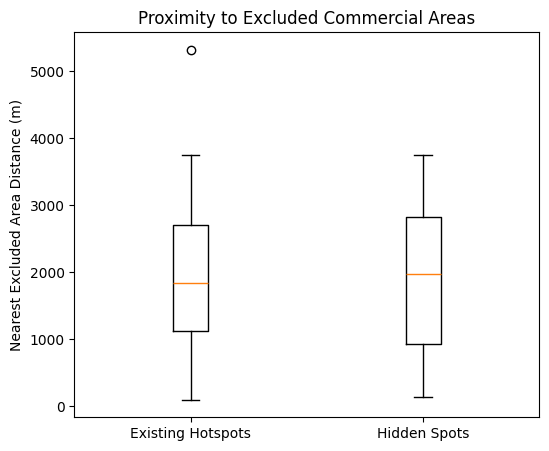

In [3]:
plt.figure(figsize=(6,5))

plt.boxplot(
    [
        H["nearest_excl_dist_m"],
        hidden["nearest_excl_dist_m"]
    ],
    labels=[
        "Existing Hotspots",
        "Hidden Spots"
    ]
)

plt.ylabel(
    "Nearest Excluded Area Distance (m)"
)

plt.title(
    "Proximity to Excluded Commercial Areas"
)

plt.show()

Hidden Spot이 기존 핫플보다
소외상권 proximity가 특별히 더 좋지는 않다

In [6]:
subway = pd.read_csv("../DATA/FEATURE/TRAFFIC/SUBWAY.csv", encoding="cp949")
subway

,역사_ID,역사명,호선,위도,경도
0,9010,동탄,수도권 광역급행철도,37.200340,127.095690
1,9009,구성,수도권 광역급행철도,37.299130,127.103890
2,9008,성남,수도권 광역급행철도,37.394670,127.120580
3,9007,수서,수도권 광역급행철도,37.486370,127.101610
4,9006,삼성,수도권 광역급행철도,37.508870,127.063240
...,...,...,...,...,...
778,154,종로5가,1호선,37.570926,127.001849
779,153,종로3가,1호선,37.570406,126.991847
780,152,종각,1호선,37.570161,126.982923
781,151,시청,1호선,37.565715,126.977088


In [11]:
food1 = pd.read_csv(
    "../DATA/FEATURE/SALES/FOOD1.csv",
    encoding="cp949",
    encoding_errors="replace",
    low_memory=False
)
food2 = pd.read_csv("../DATA/FEATURE/SALES/FOOD2.csv", encoding="cp949")

In [13]:
food1.head()

,개방자치단체코드,관리번호,인허가일자,영업상태코드,영업상태명,상세영업상태코드,상세영업상태명,폐업일자,전화번호,소재지면적,...,공장판매직종업원수,공장생산직종업원수,건물소유구분명,보증액,월세액,다중이용업소여부,시설총규모,전통업소지정번호,전통업소주된음식,홈페이지
0,3020000,3020000-101-2001-07985,2001-05-23,3,폐업,2,폐업,2007-02-07,02-796-2255,29.70,...,NaN,NaN,NaN,NaN,NaN,N,29.70,NaN,NaN,NaN
1,3230000,3230000-101-2019-00201,2019-03-26,3,폐업,2,폐업,2021-03-31,NaN,28.00,...,NaN,NaN,NaN,NaN,NaN,N,28.00,NaN,NaN,NaN
2,3120000,3120000-101-1994-02043,1994-06-15,3,폐업,2,폐업,2002-06-17,02-0393-9083,43.20,...,NaN,NaN,NaN,NaN,NaN,N,43.20,NaN,NaN,NaN
3,3110000,3110000-101-2005-00128,2005-04-26,3,폐업,2,폐업,2013-05-29,02-306-2168,190.24,...,NaN,NaN,NaN,NaN,NaN,N,190.24,NaN,NaN,NaN
4,3000000,3000000-101-2007-00202,2007-08-27,1,영업/정상,1,영업,,02-739-3345,85.26,...,NaN,NaN,NaN,NaN,NaN,N,85.26,NaN,NaN,NaN


In [14]:
food2.head()

,개방자치단체코드,관리번호,인허가일자,인허가취소일자,영업상태코드,영업상태명,상세영업상태코드,상세영업상태명,폐업일자,휴업시작일자,...,선박제원,무대면적,좌석수,기념품종류,회의실별동시수용인원,시설면적,자본금,보험시작일자,보험종료일자,시설규모
0,3050000,CDFI3261042012000002,2012-08-14,,3,폐업,3,폐업,2018-03-30,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,,NaN
1,3070000,CDFI3261042008000002,2008-03-19,,3,폐업,3,폐업,2014-06-18,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,,NaN
2,3070000,CDFI3261042008000003,2008-03-19,,3,폐업,3,폐업,2017-04-19,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,,NaN
3,3070000,CDFI3261042008000005,2008-06-13,,3,폐업,3,폐업,2018-04-09,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,,NaN
4,3070000,CDFI3261042008000006,2008-04-28,,3,폐업,3,폐업,2012-01-31,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,,NaN


In [20]:
for i in food2.columns:
    print(i)

개방자치단체코드
관리번호
인허가일자
인허가취소일자
영업상태코드
영업상태명
상세영업상태코드
상세영업상태명
폐업일자
휴업시작일자
휴업종료일자
전화번호
소재지우편번호
지번주소
도로명주소
도로명우편번호
사업장명
최종수정일자
데이터갱신구분
데이터갱신일자
좌표정보(X)
좌표정보(Y)
문화체육업종명
문화사업자구분명
지역구분명
총층수
주변환경명
제작취급품목내용
보험기관명
건물용도명
지상층수
지하층수
객실수
건축연면적
영문상호명
영문상호주소
선박총톤수
선박척수
선박제원
무대면적
좌석수
기념품종류
회의실별동시수용인원
시설면적
자본금
보험시작일자
보험종료일자
시설규모


In [19]:
for i in food1.columns:
    print(i)

개방자치단체코드
관리번호
인허가일자
영업상태코드
영업상태명
상세영업상태코드
상세영업상태명
폐업일자
전화번호
소재지면적
소재지우편번호
지번주소
도로명주소
도로명우편번호
사업장명
최종수정일자
데이터갱신구분
데이터갱신일자
업태구분명
좌표정보(X)
좌표정보(Y)
위생업태명
남성종사자수
여성종사자수
영업장주변구분명
등급구분명
급수시설구분명
본사종업원수
공장사무직종업원수
공장판매직종업원수
공장생산직종업원수
건물소유구분명
보증액
월세액
다중이용업소여부
시설총규모
전통업소지정번호
전통업소주된음식
홈페이지


| 단계             | 의미                     |
| -------------- | ---------------------- |
| Hidden Spot 선정 | 관광 혼잡 완화 후보            |
| 로컬 상권 필터링      | 정책 연계 가능 후보            |
| proximity 분석   | 소외상권과 연결 가능성 확인        |


### 소외상권 관련 제안

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 맥 한글 폰트 설정
plt.rcParams["font.family"] = "AppleGothic"

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

,순위,상권명,상권구분,자치구,행정동,위도,경도,종합점수_40_30_30,nearest_hidden_order,nearest_hidden_dist_m,...,restaurant_cnt_500m,restaurant_cnt_1000m,tour_food_cnt_500m,tour_food_cnt_1000m,need_score,hidden_proximity_score,subway_score,restaurant_score,tour_food_score,activation_priority_score
4,5,청계천공구상가,전통시장,중구,을지로동,37.567637,126.991330,98.03,3,934.515599,...,0,0,0,0,0.795967,0.880943,0.962830,0.5,0.5,0.784935
1,2,상도도깨비 골목형상점가,전통시장,동작구,상도2동,37.503406,126.937142,99.52,14,556.310333,...,0,0,0,0,0.972716,0.937477,0.614241,0.5,0.5,0.756109
11,12,테크노상가(엘리시움),전통시장,중구,신당동,37.568952,127.012938,96.00,7,138.036126,...,0,0,0,0,0.555160,1.000000,0.811458,0.5,0.5,0.716654
0,1,NH농협은행 보광동지점,골목상권,용산구,보광동,37.529047,126.999887,99.75,11,1358.092639,...,0,0,0,0,1.000000,0.817627,0.342613,0.5,0.5,0.665060
21,22,"평화시장(남평화시장, 제일평화시장, 신평화패션타운)",전통시장,중구,신당동,37.568907,127.011252,92.67,7,181.053049,...,0,0,0,0,0.160142,0.993570,0.872709,0.5,0.5,0.631605
20,21,동대문문구완구거리(동대문문구완구시장),전통시장,종로구,창신1동,37.571420,127.013855,92.70,7,423.585684,...,0,0,0,0,0.163701,0.957316,0.855499,0.5,0.5,0.619129
9,10,숭인시장,전통시장,강북구,송천동,37.613449,127.029301,96.33,2,1971.803602,...,0,1,0,0,0.594306,0.725890,0.630769,0.5,0.5,0.612741
2,3,원신초등학교(구세군관악영문교회),골목상권,관악구,삼성동,37.468092,126.930728,99.29,14,3559.401077,...,0,0,0,0,0.945433,0.488577,0.428964,0.5,0.5,0.590743
10,11,구반포역,골목상권,서초구,반포본동,37.502097,126.986802,96.06,15,3257.694818,...,0,0,0,0,0.562278,0.533676,0.711653,0.5,0.5,0.576902
15,16,노량진역 6번,골목상권,동작구,노량진2동,37.511010,126.936185,94.26,14,1260.198730,...,0,0,0,0,0.348754,0.832260,0.617788,0.5,0.5,0.574701


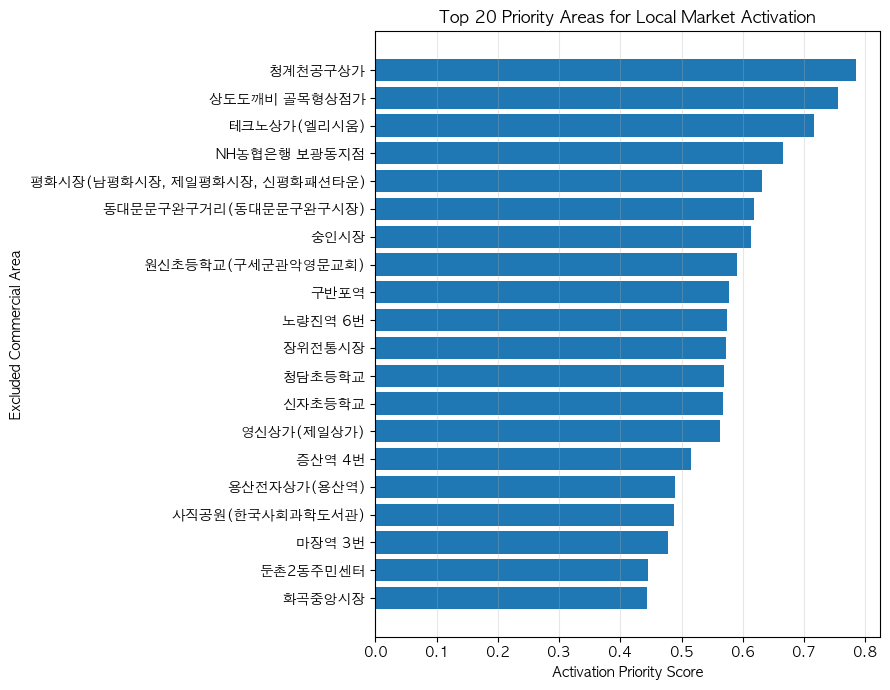

In [27]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree
import matplotlib.pyplot as plt

# =========================================================
# 0. 기본 설정
# =========================================================

EARTH_RADIUS_M = 6371000

# 좌표 컬럼 숫자화 함수
def to_numeric_coord(df, lat_col="위도", lon_col="경도"):
    df = df.copy()
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")
    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    df = df.dropna(subset=[lat_col, lon_col]).copy()
    return df


# Min-Max 정규화
def minmax(s, reverse=False):
    s = pd.to_numeric(s, errors="coerce")
    
    if s.max() == s.min():
        return pd.Series(0.5, index=s.index)
    
    score = (s - s.min()) / (s.max() - s.min())
    
    if reverse:
        score = 1 - score
    
    return score


# 최근접 거리 계산
def add_nearest_distance(
    base_df,
    target_df,
    target_name,
    base_lat="위도",
    base_lon="경도",
    target_lat="위도",
    target_lon="경도"
):
    base_df = base_df.copy()
    
    base_rad = np.radians(base_df[[base_lat, base_lon]].values)
    target_rad = np.radians(target_df[[target_lat, target_lon]].values)
    
    tree = BallTree(target_rad, metric="haversine")
    dist, idx = tree.query(base_rad, k=1)
    
    base_df[f"nearest_{target_name}_dist_m"] = dist[:, 0] * EARTH_RADIUS_M
    base_df[f"nearest_{target_name}_idx"] = idx[:, 0]
    
    return base_df


# 반경 내 개수 계산
def add_count_within_radius(
    base_df,
    target_df,
    target_name,
    radius_m,
    base_lat="위도",
    base_lon="경도",
    target_lat="위도",
    target_lon="경도"
):
    base_df = base_df.copy()
    
    base_rad = np.radians(base_df[[base_lat, base_lon]].values)
    target_rad = np.radians(target_df[[target_lat, target_lon]].values)
    
    tree = BallTree(target_rad, metric="haversine")
    indices = tree.query_radius(
        base_rad,
        r=radius_m / EARTH_RADIUS_M
    )
    
    base_df[f"{target_name}_cnt_{radius_m}m"] = [len(x) for x in indices]
    
    return base_df


# =========================================================
# 1. 좌표 정리
# =========================================================

hidden = to_numeric_coord(hidden, "위도", "경도")
excl = to_numeric_coord(excl, "위도", "경도")
subway = to_numeric_coord(subway, "위도", "경도")

# food1 / food2는 좌표정보(X), 좌표정보(Y)를 위도/경도로 변환
# 좌표정보(X) = 경도, 좌표정보(Y) = 위도

food1 = food1.rename(columns={
    "좌표정보(Y)": "위도",
    "좌표정보(X)": "경도"
})

food2 = food2.rename(columns={
    "좌표정보(Y)": "위도",
    "좌표정보(X)": "경도"
})

food1 = to_numeric_coord(food1, "위도", "경도")
food2 = to_numeric_coord(food2, "위도", "경도")


# =========================================================
# 2. 영업 중 데이터만 필터링
# =========================================================

if "영업상태명" in food1.columns:
    food1_active = food1[
        food1["영업상태명"].astype(str).str.contains("영업|정상", na=False)
    ].copy()
else:
    food1_active = food1.copy()

if "영업상태명" in food2.columns:
    food2_active = food2[
        food2["영업상태명"].astype(str).str.contains("영업|정상", na=False)
    ].copy()
else:
    food2_active = food2.copy()


# =========================================================
# 3. 소외상권 기준 Hidden Spot 최근접 거리
# =========================================================

excl = add_nearest_distance(
    base_df=excl,
    target_df=hidden,
    target_name="hidden"
)

nearest_hidden = hidden.iloc[
    excl["nearest_hidden_idx"].values
].reset_index(drop=True)

excl["nearest_hidden_order"] = nearest_hidden["selection_order"].values
excl["nearest_hidden_lat"] = nearest_hidden["위도"].values
excl["nearest_hidden_lon"] = nearest_hidden["경도"].values


# =========================================================
# 4. 지하철 접근성 feature
# =========================================================

excl = add_nearest_distance(
    base_df=excl,
    target_df=subway,
    target_name="subway"
)

excl = add_count_within_radius(
    base_df=excl,
    target_df=subway,
    target_name="subway",
    radius_m=500
)

excl = add_count_within_radius(
    base_df=excl,
    target_df=subway,
    target_name="subway",
    radius_m=1000
)


# =========================================================
# 5. 음식점 / 관광식당 feature
# =========================================================

excl = add_count_within_radius(
    base_df=excl,
    target_df=food1_active,
    target_name="restaurant",
    radius_m=500
)

excl = add_count_within_radius(
    base_df=excl,
    target_df=food1_active,
    target_name="restaurant",
    radius_m=1000
)

excl = add_count_within_radius(
    base_df=excl,
    target_df=food2_active,
    target_name="tour_food",
    radius_m=500
)

excl = add_count_within_radius(
    base_df=excl,
    target_df=food2_active,
    target_name="tour_food",
    radius_m=1000
)


# =========================================================
# 6. 활성화 우선순위 점수 계산
# =========================================================

# 1) 정책 필요성: 소외상권 위험도
excl["need_score"] = minmax(
    excl["종합점수_40_30_30"]
)

# 2) Hidden Spot 연결성: 가까울수록 높음
excl["hidden_proximity_score"] = minmax(
    excl["nearest_hidden_dist_m"],
    reverse=True
)

# 3) 지하철 접근성
excl["subway_distance_score"] = minmax(
    excl["nearest_subway_dist_m"],
    reverse=True
)

excl["subway_count_score"] = minmax(
    excl["subway_cnt_1000m"]
)

excl["subway_score"] = (
    0.6 * excl["subway_distance_score"] +
    0.4 * excl["subway_count_score"]
)

# 4) 음식점 상권
excl["restaurant_score"] = minmax(
    excl["restaurant_cnt_500m"]
)

# 5) 관광 음식
excl["tour_food_score"] = minmax(
    excl["tour_food_cnt_1000m"]
)


# =========================================================
# 7. 최종 Activation Priority Score
# =========================================================
# 도메인 중요도 반영:
# 지하철 > 음식점 상권 > 관광음식 > Hidden Spot 연결성 > 정책 필요성

excl["activation_priority_score"] = (
    0.25 * excl["need_score"] +
    0.25 * excl["hidden_proximity_score"] +
    0.25 * excl["subway_score"] +
    0.15 * excl["restaurant_score"] +
    0.10 * excl["tour_food_score"]
)


# =========================================================
# 8. 우선 활성화 후보 정렬
# =========================================================

priority_excl = excl.sort_values(
    "activation_priority_score",
    ascending=False
).copy()

priority_cols = [
    "순위",
    "상권명",
    "상권구분",
    "자치구",
    "행정동",
    "위도",
    "경도",
    "종합점수_40_30_30",
    "매출침체점수",
    "점포감소점수",
    "폐업압력점수",
    "진단_태그",
    "nearest_hidden_order",
    "nearest_hidden_dist_m",
    "nearest_subway_dist_m",
    "subway_cnt_500m",
    "subway_cnt_1000m",
    "restaurant_cnt_500m",
    "restaurant_cnt_1000m",
    "tour_food_cnt_500m",
    "tour_food_cnt_1000m",
    "need_score",
    "hidden_proximity_score",
    "subway_score",
    "restaurant_score",
    "tour_food_score",
    "activation_priority_score"
]

priority_cols = [
    col for col in priority_cols
    if col in priority_excl.columns
]

priority_result = priority_excl[priority_cols].copy()

display(priority_result.head(20))


# =========================================================
# 9. 저장
# =========================================================

priority_result.to_csv(
    "priority_excluded_markets_for_activation.csv",
    index=False,
    encoding="utf-8-sig"
)


# =========================================================
# 10. Top 20 시각화
# =========================================================

top20 = priority_result.head(20).copy()
top20 = top20.sort_values("activation_priority_score")

plt.figure(figsize=(9, 7))

plt.barh(
    top20["상권명"],
    top20["activation_priority_score"]
)

plt.xlabel("Activation Priority Score")
plt.ylabel("Excluded Commercial Area")
plt.title("Top 20 Priority Areas for Local Market Activation")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
excl22 = pd.read_csv("../DATA/LOCAL/excl22.csv")

In [29]:
import pandas as pd

# =========================
# 1. 컬럼명 정리
# =========================
priority_result = priority_result.copy()
excl22 = excl22.copy()

priority_result.columns = priority_result.columns.str.strip()
excl22.columns = excl22.columns.str.strip()

# =========================
# 2. 문자열 컬럼 공백 정리
# =========================
for df in [priority_result, excl22]:
    for col in ["상권명", "자치구", "행정동"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

# =========================
# 3. 매칭 기준 설정
# =========================
if "상권코드" in priority_result.columns and "상권코드" in excl22.columns:
    merge_keys = ["상권코드"]
else:
    merge_keys = ["상권명", "자치구", "행정동"]

print("매칭 기준:", merge_keys)

# =========================
# 4. priority_result 중 excl22에 해당하는 상권만 필터링
# =========================
priority_excl22 = priority_result.merge(
    excl22[merge_keys].drop_duplicates(),
    on=merge_keys,
    how="inner"
)

# =========================
# 5. activation_priority_score 기준 정렬
# =========================
if "activation_priority_score" in priority_excl22.columns:
    priority_excl22 = priority_excl22.sort_values(
        "activation_priority_score",
        ascending=False
    )

# =========================
# 6. 결과 확인
# =========================
print("priority_result 전체 개수:", len(priority_result))
print("excl22 전체 개수:", len(excl22))
print("매칭된 우선 활성화 후보 수:", len(priority_excl22))

display(priority_excl22)

# =========================
# 7. 저장
# =========================
priority_excl22.to_csv(
    "priority_excluded_markets_matched_excl22.csv",
    index=False,
    encoding="utf-8-sig"
)

매칭 기준: ['상권명', '자치구', '행정동']
priority_result 전체 개수: 30
excl22 전체 개수: 21
매칭된 우선 활성화 후보 수: 21


,순위,상권명,상권구분,자치구,행정동,위도,경도,종합점수_40_30_30,nearest_hidden_order,nearest_hidden_dist_m,...,restaurant_cnt_500m,restaurant_cnt_1000m,tour_food_cnt_500m,tour_food_cnt_1000m,need_score,hidden_proximity_score,subway_score,restaurant_score,tour_food_score,activation_priority_score
0,5,청계천공구상가,전통시장,중구,을지로동,37.567637,126.991330,98.03,3,934.515599,...,0,0,0,0,0.795967,0.880943,0.962830,0.5,0.5,0.784935
1,12,테크노상가(엘리시움),전통시장,중구,신당동,37.568952,127.012938,96.00,7,138.036126,...,0,0,0,0,0.555160,1.000000,0.811458,0.5,0.5,0.716654
2,1,NH농협은행 보광동지점,골목상권,용산구,보광동,37.529047,126.999887,99.75,11,1358.092639,...,0,0,0,0,1.000000,0.817627,0.342613,0.5,0.5,0.665060
3,22,"평화시장(남평화시장, 제일평화시장, 신평화패션타운)",전통시장,중구,신당동,37.568907,127.011252,92.67,7,181.053049,...,0,0,0,0,0.160142,0.993570,0.872709,0.5,0.5,0.631605
4,21,동대문문구완구거리(동대문문구완구시장),전통시장,종로구,창신1동,37.571420,127.013855,92.70,7,423.585684,...,0,0,0,0,0.163701,0.957316,0.855499,0.5,0.5,0.619129
5,10,숭인시장,전통시장,강북구,송천동,37.613449,127.029301,96.33,2,1971.803602,...,0,1,0,0,0.594306,0.725890,0.630769,0.5,0.5,0.612741
6,3,원신초등학교(구세군관악영문교회),골목상권,관악구,삼성동,37.468092,126.930728,99.29,14,3559.401077,...,0,0,0,0,0.945433,0.488577,0.428964,0.5,0.5,0.590743
7,11,구반포역,골목상권,서초구,반포본동,37.502097,126.986802,96.06,15,3257.694818,...,0,0,0,0,0.562278,0.533676,0.711653,0.5,0.5,0.576902
8,16,노량진역 6번,골목상권,동작구,노량진2동,37.511010,126.936185,94.26,14,1260.198730,...,0,0,0,0,0.348754,0.832260,0.617788,0.5,0.5,0.574701
9,7,장위전통시장,전통시장,성북구,장위2동,37.611549,127.051193,96.70,19,2325.836454,...,0,0,0,0,0.638197,0.672969,0.479379,0.5,0.5,0.572636


,selection_order,위도,경도,nearest_subway_dist_m,subway_cnt_500m,subway_cnt_1000m,subway_cnt_1500m,restaurant_cnt_500m,restaurant_cnt_1000m,tour_food_cnt_500m,tour_food_cnt_1000m
0,1,37.582331,126.983559,671.781587,0,1,6,0,0,0,0
1,2,37.630376,127.022628,507.042957,0,4,7,0,0,0,0
2,3,37.563846,126.981866,249.998392,2,9,23,0,0,0,0
3,4,37.640683,127.035490,885.962134,0,2,3,0,0,0,0
4,5,37.637817,127.038271,1104.410897,0,0,3,0,0,0,0


,순위,상권코드,상권명,상권구분,자치구,행정동,위도,경도,종합점수_40_30_30,매출증가율,...,restaurant_cnt_1000m,tour_food_cnt_500m,tour_food_cnt_1000m,need_score,hidden_proximity_score,subway_access_score,restaurant_score,tour_food_score,decline_consistency_score,activation_readiness_score
2,2,3130031,청계천공구상가,전통시장,중구,을지로동,37.567637,126.991330,98.03,-0.602626,...,0,0,0,0.795967,0.880943,0.975220,0.0,0.5,0.0,0.668985
6,10,3130140,숭인시장,전통시장,강북구,송천동,37.613449,127.029301,96.33,-0.251694,...,1,0,0,0.594306,0.725890,0.473077,1.0,0.5,1.0,0.662024
8,12,3130047,테크노상가(엘리시움),전통시장,중구,신당동,37.568952,127.012938,96.00,-0.288595,...,0,0,0,0.555160,1.000000,0.869177,0.0,0.5,1.0,0.656084
15,22,3130327,"평화시장(남평화시장, 제일평화시장, 신평화패션타운)",전통시장,중구,신당동,37.568907,127.011252,92.67,-0.150892,...,0,0,0,0.160142,0.993570,0.912575,0.0,0.5,1.0,0.566893
14,21,3130018,동대문문구완구거리(동대문문구완구시장),전통시장,종로구,창신1동,37.571420,127.013855,92.70,-0.300279,...,0,0,0,0.163701,0.957316,0.862641,0.0,0.5,1.0,0.548049
0,1,3110092,NH농협은행 보광동지점,골목상권,용산구,보광동,37.529047,126.999887,99.75,-0.738363,...,0,0,0,1.000000,0.817627,0.300204,0.0,0.5,0.0,0.538576
1,3,3110874,원신초등학교(구세군관악영문교회),골목상권,관악구,삼성동,37.468092,126.930728,99.29,-0.542646,...,0,0,0,0.945433,0.488577,0.321874,0.0,0.5,1.0,0.514542
11,16,3110828,노량진역 6번,골목상권,동작구,노량진2동,37.511010,126.936185,94.26,-0.238790,...,0,0,0,0.348754,0.832260,0.579808,0.0,0.5,1.0,0.498592
4,7,3130125,장위전통시장,전통시장,성북구,장위2동,37.611549,127.051193,96.70,-0.283410,...,0,0,0,0.638197,0.672969,0.391381,0.0,0.5,1.0,0.491988
7,11,3110908,구반포역,골목상권,서초구,반포본동,37.502097,126.986802,96.06,-0.281141,...,0,0,0,0.562278,0.533676,0.534692,0.0,0.5,1.0,0.480978


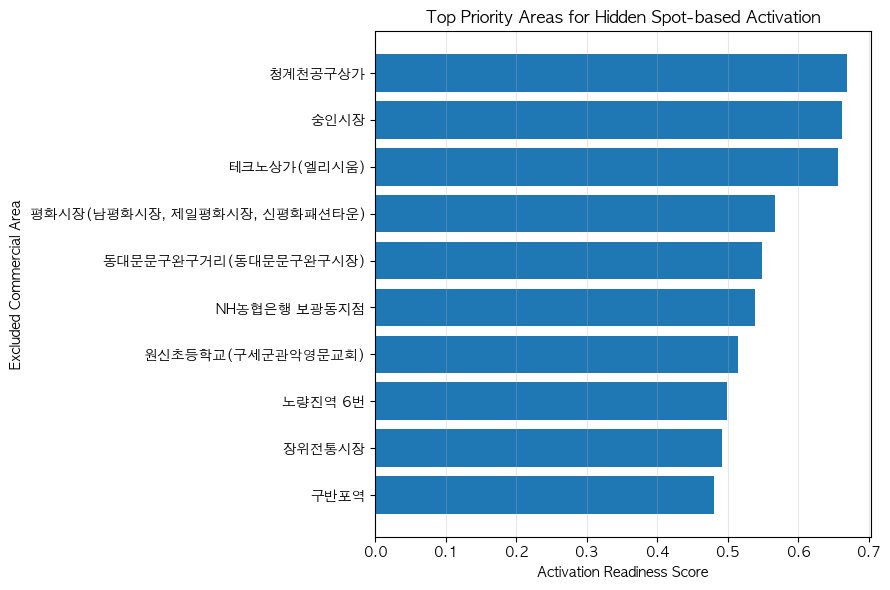


## 청계천공구상가

- 위치: 중구 을지로동
- 연결 Hidden Spot: selection_order 3
- Hidden Spot까지 거리: 934.5m
- 가장 가까운 지하철역까지 거리: 151.5m
- 1km 이내 지하철역 수: 13
- 1.5km 이내 지하철역 수: 19
- 1km 이내 일반 음식점 수: 0
- 1km 이내 관광음식 관련 지점 수: 0
- Activation Readiness Score: 0.669

### 제안 근거
청계천공구상가은 자율상권구역 기준에 부합하는 소외상권이며, 최종 Hidden Spot 21개 중 selection_order 3와 공간적으로 연결된다.
선형·비선형 분석에서 중요하게 나타난 지하철 접근성과 음식 상권 기능을 기준으로 볼 때,
해당 지역은 관광 수요를 단순히 유입시키는 것이 아니라 Hidden Spot 기반 동선을 통해 방문·체류·소비로 확장할 수 있는 후보로 해석된다.

또한 본 프로젝트의 Hidden Spot 분석에서 확인된 것처럼, 우선 개입 지역은 단순 저활성 공간이 아니라
광역 접근성과 상업 기능을 갖추되 아직 초고밀 집중이 발생하지 않은 공간과 연결될 때 정책 효과를 기대할 수 있다.


## 숭인시장

- 위치: 강북구 송천동
- 연결 Hidden Spot: selection_order 2
- Hidden Spot까지 거리: 1971.8m
- 가장 가까운 지하철역까지 거리: 68.5m
- 1km 이내 지하철역 수: 1
- 1.5km 이내 지하철역 수: 4
- 1km 이내 일반 음식점 수: 1
- 1km 이내 관광음식 관련 지점 수: 0
- Activation Readiness Score: 0.662

### 제안 근거
숭인시장은 자율상권구역 기준에 부합하는 소외상권이며, 최종 Hidden Spot 21개 중 selection_order 2와 공간적으로 연결된다.
선형·비선형 분석에서 중요하게 나타난 지하철 접근성과 음식 상권 기능을 기준으로 볼 때,
해당 지역은 관광 수요를 단순히 유입시키는

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree
import matplotlib.pyplot as plt

EARTH_RADIUS_M = 6371000

def to_numeric_coord(df, lat_col="위도", lon_col="경도"):
    df = df.copy()
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")
    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    return df.dropna(subset=[lat_col, lon_col]).copy()


def minmax(s, reverse=False):
    s = pd.to_numeric(s, errors="coerce")
    if s.max() == s.min():
        out = pd.Series(0.5, index=s.index)
    else:
        out = (s - s.min()) / (s.max() - s.min())
    return 1 - out if reverse else out


def add_nearest_distance(base_df, target_df, target_name):
    base_df = base_df.copy()
    base_rad = np.radians(base_df[["위도", "경도"]].values)
    target_rad = np.radians(target_df[["위도", "경도"]].values)

    tree = BallTree(target_rad, metric="haversine")
    dist, idx = tree.query(base_rad, k=1)

    base_df[f"nearest_{target_name}_dist_m"] = dist[:, 0] * EARTH_RADIUS_M
    base_df[f"nearest_{target_name}_idx"] = idx[:, 0]
    return base_df


def add_count_within_radius(base_df, target_df, target_name, radius_m):
    base_df = base_df.copy()
    base_rad = np.radians(base_df[["위도", "경도"]].values)
    target_rad = np.radians(target_df[["위도", "경도"]].values)

    tree = BallTree(target_rad, metric="haversine")
    indices = tree.query_radius(base_rad, r=radius_m / EARTH_RADIUS_M)

    base_df[f"{target_name}_cnt_{radius_m}m"] = [len(x) for x in indices]
    return base_df


def prepare_food(df):
    df = df.copy()

    if "좌표정보(Y)" in df.columns and "좌표정보(X)" in df.columns:
        df = df.rename(columns={
            "좌표정보(Y)": "위도",
            "좌표정보(X)": "경도"
        })

    df = to_numeric_coord(df, "위도", "경도")

    if "영업상태명" in df.columns:
        df = df[
            df["영업상태명"].astype(str).str.contains("영업|정상", na=False)
        ].copy()

    return df



hidden = to_numeric_coord(hidden, "위도", "경도")
excl22 = to_numeric_coord(excl22, "위도", "경도")
subway = to_numeric_coord(subway, "위도", "경도")

food1_active = prepare_food(food1)
food2_active = prepare_food(food2)



hidden_feat = hidden.copy()
hidden_feat["group"] = "hidden_spot"

# 지하철
hidden_feat = add_nearest_distance(hidden_feat, subway, "subway")
hidden_feat = add_count_within_radius(hidden_feat, subway, "subway", 500)
hidden_feat = add_count_within_radius(hidden_feat, subway, "subway", 1000)
hidden_feat = add_count_within_radius(hidden_feat, subway, "subway", 1500)

# 음식점 / 관광음식
hidden_feat = add_count_within_radius(hidden_feat, food1_active, "restaurant", 500)
hidden_feat = add_count_within_radius(hidden_feat, food1_active, "restaurant", 1000)
hidden_feat = add_count_within_radius(hidden_feat, food2_active, "tour_food", 500)
hidden_feat = add_count_within_radius(hidden_feat, food2_active, "tour_food", 1000)



excl22_feat = excl22.copy()
excl22_feat["group"] = "excl22"

# Hidden Spot과 연결성
excl22_feat = add_nearest_distance(excl22_feat, hidden, "hidden")
nearest_hidden = hidden.iloc[excl22_feat["nearest_hidden_idx"].values].reset_index(drop=True)

excl22_feat["nearest_hidden_order"] = nearest_hidden["selection_order"].values
excl22_feat["nearest_hidden_lat"] = nearest_hidden["위도"].values
excl22_feat["nearest_hidden_lon"] = nearest_hidden["경도"].values

# 지하철
excl22_feat = add_nearest_distance(excl22_feat, subway, "subway")
excl22_feat = add_count_within_radius(excl22_feat, subway, "subway", 500)
excl22_feat = add_count_within_radius(excl22_feat, subway, "subway", 1000)
excl22_feat = add_count_within_radius(excl22_feat, subway, "subway", 1500)

# 음식점 / 관광음식
excl22_feat = add_count_within_radius(excl22_feat, food1_active, "restaurant", 500)
excl22_feat = add_count_within_radius(excl22_feat, food1_active, "restaurant", 1000)
excl22_feat = add_count_within_radius(excl22_feat, food2_active, "tour_food", 500)
excl22_feat = add_count_within_radius(excl22_feat, food2_active, "tour_food", 1000)


#  Hidden Spot 구조와 맞는 activation score 재설계

# 논리:
# - 정책 필요성: 소외상권 점수
# - Hidden 연결성: nearest hidden distance
# - 광역 접근성: subway 1000/1500m
# - 초근접 과밀 억제: subway 500m가 지나치게 높은 경우는 감점 가능
# - 음식/관광 음식: 체류·소비 가능성

excl22_feat["need_score"] = minmax(excl22_feat["종합점수_40_30_30"])

excl22_feat["hidden_proximity_score"] = minmax(
    excl22_feat["nearest_hidden_dist_m"],
    reverse=True
)

excl22_feat["subway_nearest_score"] = minmax(
    excl22_feat["nearest_subway_dist_m"],
    reverse=True
)

excl22_feat["subway_1000_score"] = minmax(
    excl22_feat["subway_cnt_1000m"]
)

excl22_feat["subway_1500_score"] = minmax(
    excl22_feat["subway_cnt_1500m"]
)

# Hidden Spot 철학: 광역 접근성은 좋게, 초근접 과밀은 과도하게 높지 않게
excl22_feat["subway_access_score"] = (
    0.4 * excl22_feat["subway_nearest_score"] +
    0.3 * excl22_feat["subway_1000_score"] +
    0.3 * excl22_feat["subway_1500_score"]
)

excl22_feat["restaurant_score"] = minmax(
    excl22_feat["restaurant_cnt_1000m"]
)

excl22_feat["tour_food_score"] = minmax(
    excl22_feat["tour_food_cnt_1000m"]
)

# 매출/점포/인구 2년 연속 감소 충족 개수도 정책 필요성에 반영
if "2년연속감소_충족개수" in excl22_feat.columns:
    excl22_feat["decline_consistency_score"] = minmax(
        excl22_feat["2년연속감소_충족개수"]
    )
else:
    excl22_feat["decline_consistency_score"] = 0.5


# 최종 점수
excl22_feat["activation_readiness_score"] = (
    0.25 * excl22_feat["need_score"] +
    0.20 * excl22_feat["hidden_proximity_score"] +
    0.25 * excl22_feat["subway_access_score"] +
    0.15 * excl22_feat["restaurant_score"] +
    0.10 * excl22_feat["tour_food_score"] +
    0.05 * excl22_feat["decline_consistency_score"]
)

# Hidden Spot 21개와 연결된 구조 요약

hidden_summary_cols = [
    "selection_order",
    "위도", "경도",
    "nearest_subway_dist_m",
    "subway_cnt_500m",
    "subway_cnt_1000m",
    "subway_cnt_1500m",
    "restaurant_cnt_500m",
    "restaurant_cnt_1000m",
    "tour_food_cnt_500m",
    "tour_food_cnt_1000m"
]

hidden_summary_cols = [c for c in hidden_summary_cols if c in hidden_feat.columns]
hidden_feature_summary = hidden_feat[hidden_summary_cols].copy()

display(hidden_feature_summary.head())

# excl22 최종 제안 후보 정렬


proposal_cols = [
    "순위",
    "상권코드",
    "상권명",
    "상권구분",
    "자치구",
    "행정동",
    "위도", "경도",
    "종합점수_40_30_30",
    "매출증가율",
    "점포수증가율",
    "폐업압력비율",
    "2년연속감소_충족개수",
    "nearest_hidden_order",
    "nearest_hidden_dist_m",
    "nearest_subway_dist_m",
    "subway_cnt_500m",
    "subway_cnt_1000m",
    "subway_cnt_1500m",
    "restaurant_cnt_500m",
    "restaurant_cnt_1000m",
    "tour_food_cnt_500m",
    "tour_food_cnt_1000m",
    "need_score",
    "hidden_proximity_score",
    "subway_access_score",
    "restaurant_score",
    "tour_food_score",
    "decline_consistency_score",
    "activation_readiness_score"
]

proposal_cols = [c for c in proposal_cols if c in excl22_feat.columns]

proposal_result = excl22_feat.sort_values(
    "activation_readiness_score",
    ascending=False
)[proposal_cols].copy()

display(proposal_result)

proposal_result.to_csv(
    "excl22_hidden_spot_activation_proposal.csv",
    index=False,
    encoding="utf-8-sig"
)

hidden_feature_summary.to_csv(
    "hidden21_feature_summary_for_policy.csv",
    index=False,
    encoding="utf-8-sig"
)


top10 = proposal_result.head(10).sort_values("activation_readiness_score")

plt.figure(figsize=(9, 6))
plt.barh(
    top10["상권명"],
    top10["activation_readiness_score"]
)

plt.xlabel("Activation Readiness Score")
plt.ylabel("Excluded Commercial Area")
plt.title("Top Priority Areas for Hidden Spot-based Activation")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

def explain_proposal(row):
    name = row["상권명"]
    gu = row.get("자치구", "")
    dong = row.get("행정동", "")
    hidden_order = row.get("nearest_hidden_order", np.nan)
    hidden_dist = row.get("nearest_hidden_dist_m", np.nan)
    subway_dist = row.get("nearest_subway_dist_m", np.nan)
    subway_1000 = row.get("subway_cnt_1000m", np.nan)
    subway_1500 = row.get("subway_cnt_1500m", np.nan)
    rest_1000 = row.get("restaurant_cnt_1000m", np.nan)
    tour_1000 = row.get("tour_food_cnt_1000m", np.nan)
    score = row.get("activation_readiness_score", np.nan)

    return f"""
## {name}

- 위치: {gu} {dong}
- 연결 Hidden Spot: selection_order {hidden_order}
- Hidden Spot까지 거리: {hidden_dist:.1f}m
- 가장 가까운 지하철역까지 거리: {subway_dist:.1f}m
- 1km 이내 지하철역 수: {subway_1000}
- 1.5km 이내 지하철역 수: {subway_1500}
- 1km 이내 일반 음식점 수: {rest_1000}
- 1km 이내 관광음식 관련 지점 수: {tour_1000}
- Activation Readiness Score: {score:.3f}

### 제안 근거
{name}은 자율상권구역 기준에 부합하는 소외상권이며, 최종 Hidden Spot 21개 중 selection_order {hidden_order}와 공간적으로 연결된다.
선형·비선형 분석에서 중요하게 나타난 지하철 접근성과 음식 상권 기능을 기준으로 볼 때,
해당 지역은 관광 수요를 단순히 유입시키는 것이 아니라 Hidden Spot 기반 동선을 통해 방문·체류·소비로 확장할 수 있는 후보로 해석된다.

또한 본 프로젝트의 Hidden Spot 분석에서 확인된 것처럼, 우선 개입 지역은 단순 저활성 공간이 아니라
광역 접근성과 상업 기능을 갖추되 아직 초고밀 집중이 발생하지 않은 공간과 연결될 때 정책 효과를 기대할 수 있다.
"""

for _, row in proposal_result.head(5).iterrows():
    print(explain_proposal(row))

- Hidden Spot 기반 소외상권 연결
- 우선 개입 대상 도출
- 연결 Hidden Spot의 cluster 분석
(cluster별 활성화 전략이 달라야 한다)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree
EARTH_RADIUS_M = 6371000


proposal = proposal_result.copy()
hidden_spot = hidden.copy()

proposal["위도"] = pd.to_numeric(proposal["위도"], errors="coerce")
proposal["경도"] = pd.to_numeric(proposal["경도"], errors="coerce")
hidden_spot["위도"] = pd.to_numeric(hidden_spot["위도"], errors="coerce")
hidden_spot["경도"] = pd.to_numeric(hidden_spot["경도"], errors="coerce")

proposal = proposal.dropna(subset=["위도", "경도"]).copy()
hidden_spot = hidden_spot.dropna(subset=["위도", "경도"]).copy()


cluster_final_summary = pd.read_csv(
    "../RESULT/selected_21_cluster_k5_final_summary.csv"
)

cluster_final_summary.columns = cluster_final_summary.columns.str.strip()

# proposal_result 기준 가장 가까운 Hidden Spot 찾기


proposal_rad = np.radians(
    proposal[["위도", "경도"]].values
)

hidden_rad = np.radians(
    hidden_spot[["위도", "경도"]].values
)

tree = BallTree(hidden_rad, metric="haversine")

dist, idx = tree.query(proposal_rad, k=1)

proposal["nearest_hidden_dist_m"] = dist[:, 0] * EARTH_RADIUS_M
proposal["nearest_hidden_idx"] = idx[:, 0]

nearest_hidden = hidden_spot.iloc[idx[:, 0]].reset_index(drop=True)

# Hidden Spot 정보 붙이기
proposal["nearest_hidden_order"] = nearest_hidden["selection_order"].values
proposal["nearest_hidden_lat"] = nearest_hidden["위도"].values
proposal["nearest_hidden_lon"] = nearest_hidden["경도"].values

# Hidden Spot 이름 컬럼 자동 탐색
possible_name_cols = [
    "상권명", "market", "market_name", "candidate_name", "name"
]

hidden_name_col = None
for col in possible_name_cols:
    if col in hidden_spot.columns:
        hidden_name_col = col
        break

if hidden_name_col is not None:
    proposal["nearest_hidden_name"] = nearest_hidden[hidden_name_col].values
else:
    proposal["nearest_hidden_name"] = (
        "Hidden Spot #" + proposal["nearest_hidden_order"].astype(str)
    )



cluster_market_rows = []

for _, row in cluster_final_summary.iterrows():
    markets = str(row["markets"]).split(",")
    markets = [m.strip() for m in markets if m.strip()]
    
    for market in markets:
        cluster_market_rows.append({
            "nearest_hidden_name": market,
            "hidden_cluster": row["cluster"],
            "hidden_cluster_label": row["cluster_label"],
            "cluster_candidate_count": row.get("candidate_count", np.nan),
            "cluster_total_covered_h": row.get("total_covered_h", np.nan),
            "cluster_avg_covered_h": row.get("avg_covered_h", np.nan),
            "cluster_avg_x_sim": row.get("avg_x_sim", np.nan),
            "cluster_avg_c_sim_scaled": row.get("avg_c_sim_scaled", np.nan),
            "cluster_avg_local_dist_m": row.get("avg_local_dist_m", np.nan)
        })

cluster_market_long = pd.DataFrame(cluster_market_rows)

proposal = proposal.merge(
    cluster_market_long,
    on="nearest_hidden_name",
    how="left"
)


cluster_strategy_map = {
    "교통 접근형": {
        "strategy_type": "교통 접근 기반 유입 분산 전략",
        "need_to_fix": "유입은 가능하나 체류·소비 콘텐츠가 약할 수 있음",
        "policy_focus": "역세권 안내, 도보 동선, 로컬 상권 노출 강화",
        "actions": "역 출구 안내판 / 서울 관광 앱 대체 동선 / 지하철역-상권 도보 루트 / 교통 기반 쿠폰"
    },
    "생활 상업형": {
        "strategy_type": "생활 소비 기반 재방문 강화 전략",
        "need_to_fix": "관광 콘텐츠보다는 생활 소비 기반이 중심일 가능성이 높음",
        "policy_focus": "주민·방문객 혼합형 소비 프로그램 강화",
        "actions": "생활형 장보기 코스 / 전통시장 쿠폰 / 주말 플리마켓 / 지역 멤버십"
    },
    "복합 상권 다양성형": {
        "strategy_type": "다기능 소비 동선 확장 전략",
        "need_to_fix": "상권 다양성은 있으나 동선 통합과 체류 유도가 부족할 수 있음",
        "policy_focus": "쇼핑·먹거리·체험을 묶은 권역형 소비 루트 구축",
        "actions": "로컬마켓 코스 / 야간시장 / 팝업스토어 / 업종 다양성 기반 테마 지도"
    },
    "관광 소비형": {
        "strategy_type": "음식·관광 소비 체류 강화 전략",
        "need_to_fix": "관광 소비 잠재력은 있으나 과밀화 관리와 체류 품질 개선이 필요",
        "policy_focus": "대표 먹거리와 체류형 소비 콘텐츠 강화",
        "actions": "맛집 큐레이션 / 카페 코스 / 음식 축제 / SNS 방문 인증"
    },
    "관광·역사 잠재형": {
        "strategy_type": "문화·역사 스토리텔링형 체류 관광 전략",
        "need_to_fix": "문화 자원은 있으나 관광 상품화와 안내 체계가 약할 수 있음",
        "policy_focus": "역사·문화 자원을 활용한 체류형 관광 콘텐츠 구축",
        "actions": "해설 코스 / 공연·전시 연계 / 로컬 스토리텔링 투어 / 다국어 안내 콘텐츠"
    }
}

def map_cluster_value(label, key):
    if pd.isna(label):
        return np.nan
    return cluster_strategy_map.get(label, {}).get(key, np.nan)

proposal["strategy_type"] = proposal["hidden_cluster_label"].apply(
    lambda x: map_cluster_value(x, "strategy_type")
)
proposal["cluster_based_gap"] = proposal["hidden_cluster_label"].apply(
    lambda x: map_cluster_value(x, "need_to_fix")
)
proposal["policy_focus"] = proposal["hidden_cluster_label"].apply(
    lambda x: map_cluster_value(x, "policy_focus")
)
proposal["policy_actions"] = proposal["hidden_cluster_label"].apply(
    lambda x: map_cluster_value(x, "actions")
)


def diagnose_local_gap(row):
    gaps = []

    subway_cnt = row.get("subway_cnt_1000m", np.nan)
    rest_cnt = row.get("restaurant_cnt_1000m", np.nan)
    tour_cnt = row.get("tour_food_cnt_1000m", np.nan)
    hidden_dist = row.get("nearest_hidden_dist_m", np.nan)

    if pd.notna(hidden_dist):
        if hidden_dist <= 500:
            gaps.append("Hidden Spot 초근접")
        elif hidden_dist <= 1500:
            gaps.append("Hidden Spot 생활권 연결 가능")
        else:
            gaps.append("Hidden Spot과의 직접 동선 설계 필요")

    if pd.notna(subway_cnt):
        if subway_cnt >= 5:
            gaps.append("지하철 접근성 강함")
        elif subway_cnt >= 2:
            gaps.append("지하철 접근성 보통")
        else:
            gaps.append("지하철 접근성 보완 필요")

    if pd.notna(rest_cnt) and rest_cnt <= 1:
        gaps.append("일반 음식점 기반 부족")

    if pd.notna(tour_cnt) and tour_cnt <= 1:
        gaps.append("관광음식·체류 콘텐츠 부족")

    return " / ".join(gaps)

proposal["local_feature_diagnosis"] = proposal.apply(
    diagnose_local_gap,
    axis=1
)


def make_policy_summary(row):
    market = row.get("상권명", "")
    gu = row.get("자치구", "")
    dong = row.get("행정동", "")
    hidden_name = row.get("nearest_hidden_name", "")
    hidden_dist = row.get("nearest_hidden_dist_m", np.nan)
    cluster_label = row.get("hidden_cluster_label", "")
    diagnosis = row.get("local_feature_diagnosis", "")
    strategy = row.get("strategy_type", "")
    focus = row.get("policy_focus", "")
    actions = row.get("policy_actions", "")

    score = row.get("activation_readiness_score", np.nan)

    return (
        f"{market}({gu} {dong})은 가장 가까운 Hidden Spot인 '{hidden_name}'과 "
        f"약 {hidden_dist:.1f}m 거리에서 연결된다. "
        f"해당 Hidden Spot은 '{cluster_label}' 유형에 속하므로, "
        f"본 지역에는 '{strategy}'이 적합하다. "
        f"현재 지역 특성 진단 결과는 [{diagnosis}]로 나타났으며, "
        f"서울시는 {focus}에 집중할 필요가 있다. "
        f"구체적으로는 {actions} 등을 우선 검토할 수 있다. "
        f"Activation Readiness Score는 {score:.3f}이다."
    )

proposal["final_policy_summary"] = proposal.apply(
    make_policy_summary,
    axis=1
)


final_cols = [
    "상권명",
    "상권구분",
    "자치구",
    "행정동",
    "종합점수_40_30_30",
    "activation_readiness_score",

    "nearest_hidden_order",
    "nearest_hidden_name",
    "nearest_hidden_dist_m",

    "hidden_cluster",
    "hidden_cluster_label",
    "cluster_total_covered_h",
    "cluster_avg_x_sim",
    "cluster_avg_c_sim_scaled",

    "nearest_subway_dist_m",
    "subway_cnt_1000m",
    "subway_cnt_1500m",
    "restaurant_cnt_1000m",
    "tour_food_cnt_1000m",

    "local_feature_diagnosis",
    "strategy_type",
    "cluster_based_gap",
    "policy_focus",
    "policy_actions",
    "final_policy_summary"
]

final_cols = [c for c in final_cols if c in proposal.columns]

final_policy_proposal = proposal[final_cols].sort_values(
    "activation_readiness_score",
    ascending=False
).copy()

display(final_policy_proposal.head(20))


final_policy_proposal.to_csv(
    "final_policy_proposal_by_nearest_hidden_cluster.csv",
    index=False,
    encoding="utf-8-sig"
)

,상권명,상권구분,자치구,행정동,종합점수_40_30_30,activation_readiness_score,nearest_hidden_order,nearest_hidden_name,nearest_hidden_dist_m,hidden_cluster,...,subway_cnt_1000m,subway_cnt_1500m,restaurant_cnt_1000m,tour_food_cnt_1000m,local_feature_diagnosis,strategy_type,cluster_based_gap,policy_focus,policy_actions,final_policy_summary
0,청계천공구상가,전통시장,중구,을지로동,98.03,0.668985,3,Hidden Spot #3,934.515599,NaN,...,13,19,0,0,Hidden Spot 생활권 연결 가능 / 지하철 접근성 강함 / 일반 음식점 기반...,NaN,NaN,NaN,NaN,청계천공구상가(중구 을지로동)은 가장 가까운 Hidden Spot인 'Hidden ...
1,숭인시장,전통시장,강북구,송천동,96.33,0.662024,2,Hidden Spot #2,1971.803602,NaN,...,1,4,1,0,Hidden Spot과의 직접 동선 설계 필요 / 지하철 접근성 보완 필요 / 일반...,NaN,NaN,NaN,NaN,숭인시장(강북구 송천동)은 가장 가까운 Hidden Spot인 'Hidden Spo...
2,테크노상가(엘리시움),전통시장,중구,신당동,96.00,0.656084,7,Hidden Spot #7,138.036126,NaN,...,11,19,0,0,Hidden Spot 초근접 / 지하철 접근성 강함 / 일반 음식점 기반 부족 / ...,NaN,NaN,NaN,NaN,테크노상가(엘리시움)(중구 신당동)은 가장 가까운 Hidden Spot인 'Hidd...
3,"평화시장(남평화시장, 제일평화시장, 신평화패션타운)",전통시장,중구,신당동,92.67,0.566893,7,Hidden Spot #7,181.053049,NaN,...,12,19,0,0,Hidden Spot 초근접 / 지하철 접근성 강함 / 일반 음식점 기반 부족 / ...,NaN,NaN,NaN,NaN,"평화시장(남평화시장, 제일평화시장, 신평화패션타운)(중구 신당동)은 가장 가까운 H..."
4,동대문문구완구거리(동대문문구완구시장),전통시장,종로구,창신1동,92.70,0.548049,7,Hidden Spot #7,423.585684,NaN,...,10,17,0,0,Hidden Spot 초근접 / 지하철 접근성 강함 / 일반 음식점 기반 부족 / ...,NaN,NaN,NaN,NaN,동대문문구완구거리(동대문문구완구시장)(종로구 창신1동)은 가장 가까운 Hidden ...
5,NH농협은행 보광동지점,골목상권,용산구,보광동,99.75,0.538576,11,Hidden Spot #11,1358.092639,NaN,...,2,5,0,0,Hidden Spot 생활권 연결 가능 / 지하철 접근성 보통 / 일반 음식점 기반...,NaN,NaN,NaN,NaN,NH농협은행 보광동지점(용산구 보광동)은 가장 가까운 Hidden Spot인 'Hi...
6,원신초등학교(구세군관악영문교회),골목상권,관악구,삼성동,99.29,0.514542,14,Hidden Spot #14,3559.401077,NaN,...,1,3,0,0,Hidden Spot과의 직접 동선 설계 필요 / 지하철 접근성 보완 필요 / 일반...,NaN,NaN,NaN,NaN,원신초등학교(구세군관악영문교회)(관악구 삼성동)은 가장 가까운 Hidden Spot...
7,노량진역 6번,골목상권,동작구,노량진2동,94.26,0.498592,14,Hidden Spot #14,1260.198730,NaN,...,7,10,0,0,Hidden Spot 생활권 연결 가능 / 지하철 접근성 강함 / 일반 음식점 기반...,NaN,NaN,NaN,NaN,노량진역 6번(동작구 노량진2동)은 가장 가까운 Hidden Spot인 'Hidde...
8,장위전통시장,전통시장,성북구,장위2동,96.70,0.491988,19,Hidden Spot #19,2325.836454,NaN,...,2,5,0,0,Hidden Spot과의 직접 동선 설계 필요 / 지하철 접근성 보통 / 일반 음식...,NaN,NaN,NaN,NaN,장위전통시장(성북구 장위2동)은 가장 가까운 Hidden Spot인 'Hidden ...
9,구반포역,골목상권,서초구,반포본동,96.06,0.480978,15,Hidden Spot #15,3257.694818,NaN,...,4,4,0,0,Hidden Spot과의 직접 동선 설계 필요 / 지하철 접근성 보통 / 일반 음식...,NaN,NaN,NaN,NaN,구반포역(서초구 반포본동)은 가장 가까운 Hidden Spot인 'Hidden Sp...


In [ ]:
df = final_policy_proposal.copy()

if "activation_readiness_score" in df.columns:
    df = df.sort_values("activation_readiness_score", ascending=False).reset_index(drop=True)

cluster_desc = {
    "교통 접근형": {
        "핵심 특징": "지하철·대중교통 접근성이 높고 외부 유입이 쉬운 유형",
        "강점": "방문 유도, 혼잡 수요 분산, 역세권 안내 연계",
        "보완점": "방문 이후 체류·소비 콘텐츠 강화 필요",
        "정책 방향": "역세권 기반 유입 분산 + 도보 동선 안내"
    },
    "생활 상업형": {
        "핵심 특징": "지역 생활 소비 기반이 존재하는 유형",
        "강점": "주민 소비, 반복 방문, 생활형 상권 안정성",
        "보완점": "외부 관광객을 끌어들일 콘텐츠 부족 가능",
        "정책 방향": "생활 소비 강화 + 지역 커뮤니티형 프로그램"
    },
    "복합 상권 다양성형": {
        "핵심 특징": "쇼핑·먹거리·체험 등 다양한 소비 기능이 혼재된 유형",
        "강점": "권역형 소비 동선, 업종 다양성, 체류 확장 가능성",
        "보완점": "상권 간 연결 동선과 테마 구성 필요",
        "정책 방향": "로컬마켓 코스 + 야간시장 + 팝업 콘텐츠"
    },
    "관광 소비형": {
        "핵심 특징": "음식·관광 소비 기능이 강한 유형",
        "강점": "맛집, 카페, 체류형 소비 전환",
        "보완점": "과밀화 관리와 소비 품질 관리 필요",
        "정책 방향": "대표 먹거리 큐레이션 + 체류형 소비 콘텐츠"
    },
    "관광·역사 잠재형": {
        "핵심 특징": "역사·문화·공연 자원이 강한 유형",
        "강점": "스토리텔링, 문화 해설, 체류형 관광",
        "보완점": "관광 상품화와 안내 체계 보완 필요",
        "정책 방향": "문화·역사 해설 코스 + 다국어 관광 콘텐츠"
    }
}

cluster_summary_table = pd.DataFrame([
    {
        "Cluster 유형": k,
        "핵심 특징": v["핵심 특징"],
        "강점": v["강점"],
        "보완점": v["보완점"],
        "정책 방향": v["정책 방향"]
    }
    for k, v in cluster_desc.items()
])

display(cluster_summary_table)


def classify_hidden_connection(dist):
    if pd.isna(dist):
        return "Hidden Spot 연결 정보 부족"
    if dist <= 500:
        return "Hidden Spot 초근접권"
    elif dist <= 1500:
        return "Hidden Spot 생활권 연계 가능"
    elif dist <= 3000:
        return "Hidden Spot 확장 연계권"
    else:
        return "Hidden Spot과 직접 동선 설계 필요"


def classify_subway(row):
    nearest = row.get("nearest_subway_dist_m", np.nan)
    cnt1000 = row.get("subway_cnt_1000m", np.nan)
    cnt1500 = row.get("subway_cnt_1500m", np.nan)

    if pd.notna(cnt1000) and cnt1000 >= 5:
        return "지하철 접근성 매우 강함"
    elif pd.notna(nearest) and nearest <= 300:
        return "최근접 지하철 접근성 우수"
    elif pd.notna(cnt1500) and cnt1500 >= 3:
        return "광역 지하철 접근성 보유"
    else:
        return "지하철 접근성 보완 필요"


def classify_food(row):
    rest = row.get("restaurant_cnt_1000m", np.nan)
    tour = row.get("tour_food_cnt_1000m", np.nan)

    if pd.isna(rest) and pd.isna(tour):
        return "음식·관광소비 인프라 확인 필요"

    if rest <= 1 and tour <= 1:
        return "음식·관광 체류 콘텐츠 부족"
    elif rest <= 1:
        return "일반 음식점 기반 부족"
    elif tour <= 1:
        return "관광음식 콘텐츠 부족"
    else:
        return "음식·관광소비 기반 보유"


def get_cluster_policy(cluster_label):
    if pd.isna(cluster_label) or cluster_label not in cluster_desc:
        return {
            "핵심 특징": "클러스터 정보 없음",
            "정책 방향": "근접 Hidden Spot의 세부 유형 확인 필요"
        }
    return cluster_desc[cluster_label]


def recommend_policy(row):
    connection = classify_hidden_connection(row.get("nearest_hidden_dist_m", np.nan))
    subway = classify_subway(row)
    food = classify_food(row)
    cluster_label = row.get("hidden_cluster_label", np.nan)
    cluster_info = get_cluster_policy(cluster_label)

    proposals = []

    # Hidden Spot 거리 기반
    if "초근접" in connection:
        proposals.append("근접 Hidden Spot과 소외상권을 하나의 도보권 코스로 묶어 안내한다.")
    elif "생활권" in connection:
        proposals.append("Hidden Spot 방문 이후 이동 가능한 생활권 확장 코스를 설계한다.")
    elif "확장" in connection:
        proposals.append("직접 도보 이동보다 지하철·버스 환승 기반 연계 동선을 설계한다.")
    else:
        proposals.append("Hidden Spot과 바로 연결하기보다 별도 권역형 활성화 전략을 병행한다.")

    # 클러스터 기반
    proposals.append(f"연결 Hidden Spot의 유형이 '{cluster_label}'이므로, {cluster_info['정책 방향']}을 중심 전략으로 설정한다.")

    # 지하철 기반
    if "매우 강함" in subway or "우수" in subway:
        proposals.append("지하철역 출구, 역사 안내판, 서울 관광 앱을 통해 상권 노출을 강화한다.")
    elif "광역" in subway:
        proposals.append("광역 접근성을 활용해 주말·이벤트형 방문 수요를 유도한다.")
    else:
        proposals.append("대중교통 접근 안내와 보행 동선 정비를 우선 추진한다.")

    # 음식/체류 기반
    if "부족" in food:
        proposals.append("먹거리, 카페, 체험형 팝업, 야간 콘텐츠를 보완해 체류 시간을 늘린다.")
    else:
        proposals.append("기존 음식·관광소비 자원을 큐레이션해 방문객 소비 전환을 강화한다.")

    return proposals


def make_area_report(row):
    name = row.get("상권명", "")
    gu = row.get("자치구", "")
    dong = row.get("행정동", "")
    score = row.get("activation_readiness_score", np.nan)

    hidden_name = row.get("nearest_hidden_name", f"Hidden Spot #{row.get('nearest_hidden_order', '')}")
    hidden_order = row.get("nearest_hidden_order", "")
    hidden_dist = row.get("nearest_hidden_dist_m", np.nan)

    cluster_label = row.get("hidden_cluster_label", np.nan)
    cluster_info = get_cluster_policy(cluster_label)

    subway_dist = row.get("nearest_subway_dist_m", np.nan)
    subway1000 = row.get("subway_cnt_1000m", np.nan)
    subway1500 = row.get("subway_cnt_1500m", np.nan)
    rest1000 = row.get("restaurant_cnt_1000m", np.nan)
    tour1000 = row.get("tour_food_cnt_1000m", np.nan)

    connection_type = classify_hidden_connection(hidden_dist)
    subway_type = classify_subway(row)
    food_type = classify_food(row)

    proposals = recommend_policy(row)

    md = f"""
## {name}

### 1. 기본 정보
- 위치: {gu} {dong}
- 상권구분: {row.get("상권구분", "")}
- 종합 소외 점수: {row.get("종합점수_40_30_30", np.nan):.2f}
- Activation Readiness Score: {score:.3f}

### 2. 근접 Hidden Spot 및 Cluster
- 연결 Hidden Spot: {hidden_name}
- Hidden Spot selection_order: {hidden_order}
- Hidden Spot까지 거리: {hidden_dist:.1f}m
- 연결 유형: {connection_type}
- 연결 Hidden Spot Cluster: {cluster_label}
- Cluster 핵심 특징: {cluster_info.get("핵심 특징", "")}
- Cluster 정책 방향: {cluster_info.get("정책 방향", "")}

### 3. 현재 지역 특성
- 가장 가까운 지하철역까지 거리: {subway_dist:.1f}m
- 1km 이내 지하철역 수: {subway1000}
- 1.5km 이내 지하철역 수: {subway1500}
- 1km 이내 일반 음식점 수: {rest1000}
- 1km 이내 관광음식 관련 지점 수: {tour1000}

### 4. 진단
- 교통 접근성: {subway_type}
- 체류·소비 인프라: {food_type}
- Cluster 대비 보완점: {cluster_info.get("보완점", "")}

### 5. 서울시 제안 방향
"""
    for p in proposals:
        md += f"- {p}\n"

    md += f"""
### 6. 종합 해석
{name}은 자율상권구역 기준에 부합하는 소외상권이며, 근접 Hidden Spot의 cluster 유형을 고려할 때 
단일한 활성화 방식보다 해당 cluster의 도시 기능 구조에 맞춘 전략이 필요하다. 
현재 분석 결과에서 접근성은 일정 수준 확보된 경우가 많지만, 음식·관광소비·체류 콘텐츠가 부족한 경우가 많다. 
따라서 서울시는 단순 유입 확대보다 방문 이후 체류와 소비로 전환되는 콘텐츠 보완에 집중할 필요가 있다.
"""
    return md


cluster_summary_md = "# Hidden Spot Cluster별 정책 해석 요약\n\n"
cluster_summary_md += cluster_summary_table.to_markdown(index=False)
cluster_summary_md += "\n\n---\n\n# 지역별 맞춤형 정책 제안\n"


top_n = 10

report_blocks = []

for _, row in df.head(top_n).iterrows():
    report_blocks.append(make_area_report(row))

report_text = cluster_summary_md + "\n\n---\n\n".join(report_blocks)

print(report_text)

with open(
    "final_area_policy_reports_with_cluster.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(report_text)

print("저장 완료: final_area_policy_reports_with_cluster.md")

,Cluster 유형,핵심 특징,강점,보완점,정책 방향
0,교통 접근형,지하철·대중교통 접근성이 높고 외부 유입이 쉬운 유형,"방문 유도, 혼잡 수요 분산, 역세권 안내 연계",방문 이후 체류·소비 콘텐츠 강화 필요,역세권 기반 유입 분산 + 도보 동선 안내
1,생활 상업형,지역 생활 소비 기반이 존재하는 유형,"주민 소비, 반복 방문, 생활형 상권 안정성",외부 관광객을 끌어들일 콘텐츠 부족 가능,생활 소비 강화 + 지역 커뮤니티형 프로그램
2,복합 상권 다양성형,쇼핑·먹거리·체험 등 다양한 소비 기능이 혼재된 유형,"권역형 소비 동선, 업종 다양성, 체류 확장 가능성",상권 간 연결 동선과 테마 구성 필요,로컬마켓 코스 + 야간시장 + 팝업 콘텐츠
3,관광 소비형,음식·관광 소비 기능이 강한 유형,"맛집, 카페, 체류형 소비 전환",과밀화 관리와 소비 품질 관리 필요,대표 먹거리 큐레이션 + 체류형 소비 콘텐츠
4,관광·역사 잠재형,역사·문화·공연 자원이 강한 유형,"스토리텔링, 문화 해설, 체류형 관광",관광 상품화와 안내 체계 보완 필요,문화·역사 해설 코스 + 다국어 관광 콘텐츠


# Hidden Spot Cluster별 정책 해석 요약

| Cluster 유형       | 핵심 특징                                           | 강점                                            | 보완점                                  | 정책 방향                                 |
|:-------------------|:----------------------------------------------------|:------------------------------------------------|:----------------------------------------|:------------------------------------------|
| 교통 접근형        | 지하철·대중교통 접근성이 높고 외부 유입이 쉬운 유형 | 방문 유도, 혼잡 수요 분산, 역세권 안내 연계     | 방문 이후 체류·소비 콘텐츠 강화 필요    | 역세권 기반 유입 분산 + 도보 동선 안내    |
| 생활 상업형        | 지역 생활 소비 기반이 존재하는 유형                 | 주민 소비, 반복 방문, 생활형 상권 안정성        | 외부 관광객을 끌어들일 콘텐츠 부족 가능 | 생활 소비 강화 + 지역 커뮤니티형 프로그램 |
| 복합 상권 다양성형 | 쇼핑·먹거리·체험 등 다양한 소비 기능이 혼재된 유형  | 권역형 소비 동선, 업종 다양성, 체류 확장 가능성 | 상권 간 연결 동선과 테마 구성 필요      | 로컬마켓 코스 + 야간시장 + 팝업 콘텐츠    |
| 관광 소비형        | 음식·관광 소비 기능이 강한 유형                     | 맛집, 카페, 체류형 소비 전환                    | 과밀화 관리와 소비 품질 관리 필요       | 대표 먹거리 큐레이션 

In [1]:
import pandas as pd
df = pd.read_csv("excl22_hidden_spot_activation_proposal.csv")

In [2]:
df

,순위,상권코드,상권명,상권구분,자치구,행정동,위도,경도,종합점수_40_30_30,매출증가율,...,restaurant_cnt_1000m,tour_food_cnt_500m,tour_food_cnt_1000m,need_score,hidden_proximity_score,subway_access_score,restaurant_score,tour_food_score,decline_consistency_score,activation_readiness_score
0,2,3130031,청계천공구상가,전통시장,중구,을지로동,37.567637,126.991330,98.03,-0.602626,...,0,0,0,0.795967,0.880943,0.975220,0.0,0.5,0.0,0.668985
1,10,3130140,숭인시장,전통시장,강북구,송천동,37.613449,127.029301,96.33,-0.251694,...,1,0,0,0.594306,0.725890,0.473077,1.0,0.5,1.0,0.662024
2,12,3130047,테크노상가(엘리시움),전통시장,중구,신당동,37.568952,127.012938,96.00,-0.288595,...,0,0,0,0.555160,1.000000,0.869177,0.0,0.5,1.0,0.656084
3,22,3130327,"평화시장(남평화시장, 제일평화시장, 신평화패션타운)",전통시장,중구,신당동,37.568907,127.011252,92.67,-0.150892,...,0,0,0,0.160142,0.993570,0.912575,0.0,0.5,1.0,0.566893
4,21,3130018,동대문문구완구거리(동대문문구완구시장),전통시장,종로구,창신1동,37.571420,127.013855,92.70,-0.300279,...,0,0,0,0.163701,0.957316,0.862641,0.0,0.5,1.0,0.548049
5,1,3110092,NH농협은행 보광동지점,골목상권,용산구,보광동,37.529047,126.999887,99.75,-0.738363,...,0,0,0,1.000000,0.817627,0.300204,0.0,0.5,0.0,0.538576
6,3,3110874,원신초등학교(구세군관악영문교회),골목상권,관악구,삼성동,37.468092,126.930728,99.29,-0.542646,...,0,0,0,0.945433,0.488577,0.321874,0.0,0.5,1.0,0.514542
7,16,3110828,노량진역 6번,골목상권,동작구,노량진2동,37.511010,126.936185,94.26,-0.238790,...,0,0,0,0.348754,0.832260,0.579808,0.0,0.5,1.0,0.498592
8,7,3130125,장위전통시장,전통시장,성북구,장위2동,37.611549,127.051193,96.70,-0.283410,...,0,0,0,0.638197,0.672969,0.391381,0.0,0.5,1.0,0.491988
9,11,3110908,구반포역,골목상권,서초구,반포본동,37.502097,126.986802,96.06,-0.281141,...,0,0,0,0.562278,0.533676,0.534692,0.0,0.5,1.0,0.480978


In [4]:
df.columns

Index(['순위', '상권코드', '상권명', '상권구분', '자치구', '행정동', '위도', '경도', '종합점수_40_30_30',
       '매출증가율', '점포수증가율', '폐업압력비율', '2년연속감소_충족개수', 'nearest_hidden_order',
       'nearest_hidden_dist_m', 'nearest_subway_dist_m', 'subway_cnt_500m',
       'subway_cnt_1000m', 'subway_cnt_1500m', 'restaurant_cnt_500m',
       'restaurant_cnt_1000m', 'tour_food_cnt_500m', 'tour_food_cnt_1000m',
       'need_score', 'hidden_proximity_score', 'subway_access_score',
       'restaurant_score', 'tour_food_score', 'decline_consistency_score',
       'activation_readiness_score'],
      dtype='str')

In [3]:
df["상권명"].unique

<bound method Series.unique of 0                          청계천공구상가
1                             숭인시장
2                      테크노상가(엘리시움)
3     평화시장(남평화시장, 제일평화시장, 신평화패션타운)
4             동대문문구완구거리(동대문문구완구시장)
5                     NH농협은행 보광동지점
6                원신초등학교(구세군관악영문교회)
7                          노량진역 6번
8                           장위전통시장
9                             구반포역
10                          신자초등학교
11                     용산전자상가(용산역)
12                          마장역 3번
13                          증산역 4번
14                       구로119안전센터
15                          화곡중앙시장
16                         갈현건영아파트
17                         연신내역 7번
18                         국악고교사거리
19                            영신여고
20               KT금천빌딩(금천구시설관리공단)
Name: 상권명, dtype: str>

In [12]:
target_names = [
    "청계천공구상가",
    "테크노상가(엘리시움)",
    "평화시장(남평화시장, 제일평화시장, 신평화패션타운)",
    "동대문문구완구거리(동대문문구완구시장)"
]

A = df.loc[
    df["상권명"].isin(target_names),
    ["상권명", "자치구", "행정동", "위도", "경도"]
]

In [13]:
A

,상권명,자치구,행정동,위도,경도
0,청계천공구상가,중구,을지로동,37.567637,126.991330
2,테크노상가(엘리시움),중구,신당동,37.568952,127.012938
3,"평화시장(남평화시장, 제일평화시장, 신평화패션타운)",중구,신당동,37.568907,127.011252
4,동대문문구완구거리(동대문문구완구시장),종로구,창신1동,37.571420,127.013855


In [14]:
import folium

# 중심 좌표: A 데이터의 평균 위도/경도
center_lat = A["위도"].mean()
center_lon = A["경도"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=15,
    tiles="CartoDB positron"
)

# 마커 추가
for _, row in A.iterrows():
    folium.Marker(
        location=[row["위도"], row["경도"]],
        popup=f"""
        <b>{row["상권명"]}</b><br>
        자치구: {row["자치구"]}<br>
        행정동: {row["행정동"]}
        """,
        tooltip=row["상권명"]
    ).add_to(m)

# html 저장
m.save("A_map.html")

In [16]:
target_names = [
    "NH농협은행 보광동지점",
    "노량진역 6번"
]

A = df.loc[
    df["상권명"].isin(target_names),
    ["상권명", "자치구", "행정동", "위도", "경도"]
]

In [18]:
A

,상권명,자치구,행정동,위도,경도
5,NH농협은행 보광동지점,용산구,보광동,37.529047,126.999887
7,노량진역 6번,동작구,노량진2동,37.511010,126.936185


In [17]:
import folium

# 중심 좌표: A 데이터의 평균 위도/경도
center_lat = A["위도"].mean()
center_lon = A["경도"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=15,
    tiles="CartoDB positron"
)

# 마커 추가
for _, row in A.iterrows():
    folium.Marker(
        location=[row["위도"], row["경도"]],
        popup=f"""
        <b>{row["상권명"]}</b><br>
        자치구: {row["자치구"]}<br>
        행정동: {row["행정동"]}
        """,
        tooltip=row["상권명"]
    ).add_to(m)

# html 저장
m.save("B_map.html")

In [19]:
target_names = [
    "숭인시장",
    "원신초등학교(구세군관악영문교회)",
    "장위전통시장",
    "구반포역"
]

A = df.loc[
    df["상권명"].isin(target_names),
    ["상권명", "자치구", "행정동", "위도", "경도"]
]

In [20]:
A

,상권명,자치구,행정동,위도,경도
1,숭인시장,강북구,송천동,37.613449,127.029301
6,원신초등학교(구세군관악영문교회),관악구,삼성동,37.468092,126.930728
8,장위전통시장,성북구,장위2동,37.611549,127.051193
9,구반포역,서초구,반포본동,37.502097,126.986802


In [21]:
import folium

# 중심 좌표: A 데이터의 평균 위도/경도
center_lat = A["위도"].mean()
center_lon = A["경도"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=15,
    tiles="CartoDB positron"
)

# 마커 추가
for _, row in A.iterrows():
    folium.Marker(
        location=[row["위도"], row["경도"]],
        popup=f"""
        <b>{row["상권명"]}</b><br>
        자치구: {row["자치구"]}<br>
        행정동: {row["행정동"]}
        """,
        tooltip=row["상권명"]
    ).add_to(m)

# html 저장
m.save("C_map.html")